In [1]:
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

plt.style.use("ggplot")
%matplotlib inline

In [2]:
model = joblib.load("../models/final_gradient_boosting.pkl")

In [3]:
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

In [4]:
predictions = model.predict(X_test)

In [5]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

MAE : 10.03
RMSE: 27.69
R²  : 0.9432


In [6]:
evaluation = pd.DataFrame({
    "Metric":[
        "MAE",
        "RMSE",
        "R²"
    ],
    "Value":[
        mae,
        rmse,
        r2
    ]
})

evaluation

,Metric,Value
0,MAE,10.034491
1,RMSE,27.692860
2,R²,0.943240


In [7]:
evaluation.to_csv(
    "../data/final_model_metrics.csv",
    index=False
)

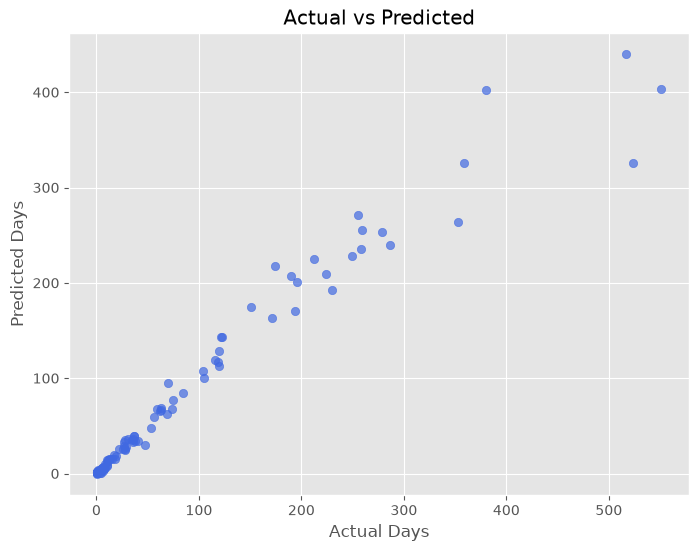

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Days")
plt.ylabel("Predicted Days")
plt.title("Actual vs Predicted")

plt.show()



plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7,
    color="royalblue"
)

plt.xlabel("Actual Days")
plt.ylabel("Predicted Days")

plt.title("Actual vs Predicted")

plt.show()

### Observation

The predictions closely follow the actual values, indicating that the Gradient Boosting model captures the relationship between song characteristics and playlist survival effectively.

In [9]:
residuals = y_test - predictions

residuals.head()

0    -0.240293
1   -16.456429
2     3.160816
3    37.695983
4    -1.116717
Name: days_on_playlist, dtype: float64

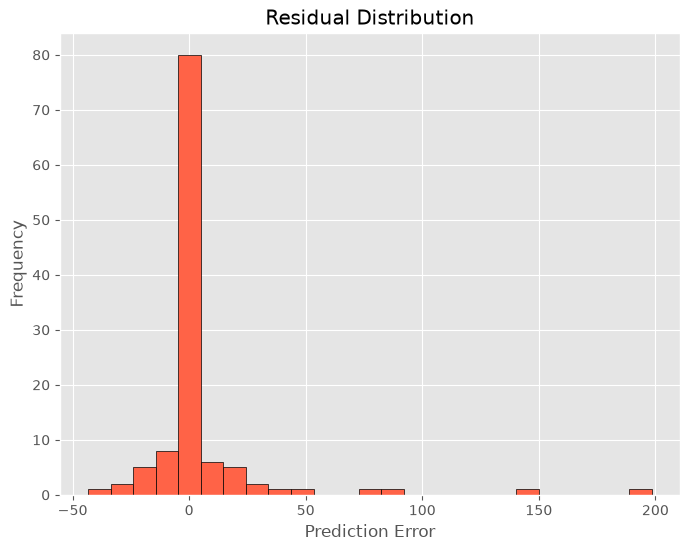

In [10]:
plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=25,
    edgecolor="black",
    color="tomato"
)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

### Observation

Residuals are concentrated around zero, indicating that prediction errors are generally small. A few larger errors exist for songs with exceptionally long playlist durations.

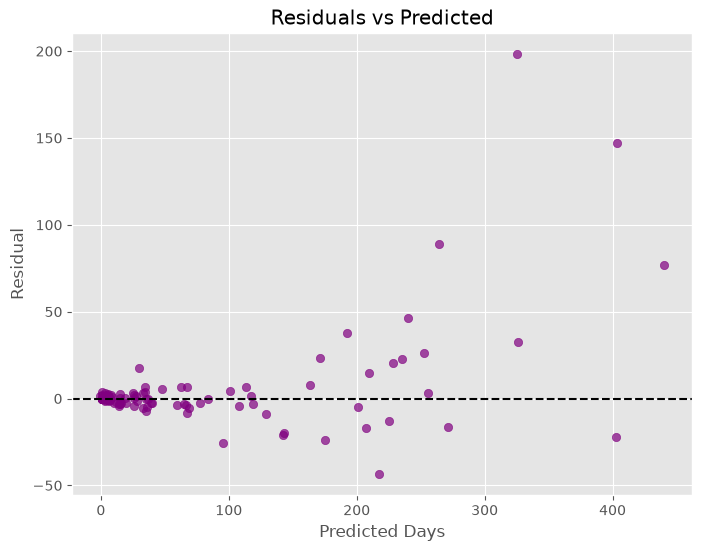

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    color="purple",
    alpha=0.7
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.xlabel("Predicted Days")
plt.ylabel("Residual")

plt.title("Residuals vs Predicted")

plt.show()

### Observation

Residuals are randomly scattered around zero without a clear pattern, suggesting that the model does not exhibit systematic bias.

In [12]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
    "Residual": residuals
})

results.head()

,Actual,Predicted,Residual
0,1,1.240293,-0.240293
1,255,271.456429,-16.456429
2,6,2.839184,3.160816
3,230,192.304017,37.695983
4,6,7.116717,-1.116717


In [13]:
results.to_csv(
    "../data/model_predictions.csv",
    index=False
)

### Final Model Summary

The tuned Gradient Boosting Regressor achieved strong predictive performance with a high R² score and low MAE/RMSE values. The model accurately estimates how long songs remain on the Spotify Spain Top 50 playlist using engineered lifecycle and popularity features.

### Business Insights

• Playlist entries and stability score are the strongest predictors of playlist longevity.
• Songs with stable rankings are more likely to remain on the chart.
• Rank volatility negatively affects playlist survival.
• The model can help record labels identify songs with high long-term chart potential and optimize promotional strategies.